Number of observations: 25
Number of predictors: 3

OUTER LOOCV FOLD 1/25
Training observations = 24
Test observation       = 1
Observed  = 3.510000
Predicted = 1.973900
Best parameters:
{'rf__max_depth': None, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}

OUTER LOOCV FOLD 2/25
Training observations = 24
Test observation       = 1
Observed  = 1.600000
Predicted = 3.219179
Best parameters:
{'rf__max_depth': None, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 4, 'rf__n_estimators': 50}

OUTER LOOCV FOLD 3/25
Training observations = 24
Test observation       = 1
Observed  = 5.910000
Predicted = 5.449163
Best parameters:
{'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 4, 'rf__n_estimators': 50}

OUTER LOOCV FOLD 4/25
Training observations = 24
Test observation       = 1
Observed  = 2.010000
Predicted = 1.499098
Best parameters:
{'rf__max_depth': No

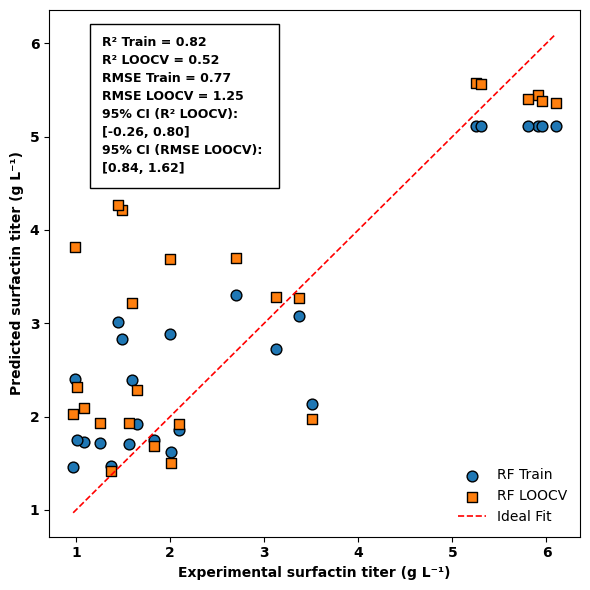

In [1]:

# RF model training with hyperparameter tuning using grid search and validation using nested LOOCV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error



# 1. Load data of input-output features

data  = r"define datafile path"

# create dataframe of the input features
df = pd.read_csv(data)

# Stack the input features 
X_real = np.column_stack((
    df.TEMP,
    df.SPEED,
    df.INNOCULUM
   
))

#Target varible (Surfactin titer)
y = df["SURFACTIN"].values


X = np.asarray(X_real)
y = np.asarray(y).ravel()

print("Number of observations:", X.shape[0])
print("Number of predictors:", X.shape[1])



# 2. Outer LOOCV

outer_loo = LeaveOneOut()

# Store prediction for every outer left-out observation
y_pred_LOOCV = np.zeros(len(y))

# Store best hyperparameters from every outer fold
best_params = []



# 3. Random forest pipeline

rf_pipeline = Pipeline([
    ("rf", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])



# 4. Define hyperparameter grid 

param_grid = {

    "rf__n_estimators": [
        50,
        100,
        200,
        300
    ],

    "rf__max_depth": [
        None,
        3,
        5,
        10
    ],

    "rf__min_samples_split": [
        2,
        4,
        6,
        10
    ],

    "rf__min_samples_leaf": [
        1,
        2,
        3,
        4,
        5
    ],

    "rf__max_features": [
        0.3,
        0.5,
        0.7,
        1.0
        
    ]
}



# 5. Nested LOOCV

for fold, (train_idx, test_idx) in enumerate(
        outer_loo.split(X), start=1):

    print("\n" + "=" * 60)
    print(f"OUTER LOOCV FOLD {fold}/{len(y)}")
    print("=" * 60)



    # Outer training data

    X_train = X[train_idx]
    y_train = y[train_idx]



    # Outer test data

    X_test = X[test_idx]
    y_test = y[test_idx]


    print(
        f"Training observations = {len(train_idx)}"
    )

    print(
        f"Test observation       = {len(test_idx)}"
    )


  
    # Inner LOOCV

    inner_loo = LeaveOneOut()


 
    # Grid search using only outer-training observations
 

    grid_search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=inner_loo,
        n_jobs=-1,
        refit=True
    )


    # Hyperparameter tuning


    grid_search.fit(
        X_train,
        y_train
    )



    # Best RF model from inner LOOCV


    best_model = grid_search.best_estimator_


    # Best parameters for this outer fold


    fold_params = grid_search.best_params_

    best_params.append(fold_params)



    # Predict outer left-out observation
 

    prediction = best_model.predict(X_test)[0]

    y_pred_LOOCV[test_idx[0]] = prediction


   
    # Display fold results


    print(
        f"Observed  = {y_test[0]:.6f}"
    )

    print(
        f"Predicted = {prediction:.6f}"
    )

    print(
        "Best parameters:"
    )

    print(
        fold_params
    )



# 6. Nested LOOCV performance metrics


R2_LOOCV = r2_score(
    y,
    y_pred_LOOCV
)

RMSE_LOOCV = np.sqrt(
    mean_squared_error(
        y,
        y_pred_LOOCV
    )
)


print("\n")
print("=" * 60)
print("Random forest nested LOOCV performance")
print("=" * 60)

print(
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)



# 7. Final RF hyperparameter optimization

print("\n")
print("=" * 60)
print("FINAL RF hyperparameter optimization")
print("=" * 60)



# Inner LOOCV using all 25 observations

final_inner_loo = LeaveOneOut()


final_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=final_inner_loo,
    n_jobs=-1,
    refit=True
)



# Tune using all 25 real observations

final_grid.fit(
    X,
    y
)



# Final optimized Random Forest model

final_model = final_grid.best_estimator_


print(
    "Final optimal parameters:"
)

print(
    final_grid.best_params_
)



# 8. Final train predictions

y_pred_train = final_model.predict(X)



# 9. Training performance metrics

R2_train = r2_score(
    y,
    y_pred_train
)

RMSE_train = np.sqrt(
    mean_squared_error(
        y,
        y_pred_train
    )
)


print("\n")
print("=" * 60)
print("Training performance metrics")
print("=" * 60)

print(
    f"Train R²   = {R2_train:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f}"
)



# 10. Comparison of train and nested LOOCV performance metrics

print("\n")
print("=" * 60)
print("TRAIN vs NESTED LOOCV")
print("=" * 60)

print(
    f"Train R²   = {R2_train:.4f} | "
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f} | "
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)



# 11. Observed vs predicted values


results = pd.DataFrame({

    "Observation":
        np.arange(1, len(y) + 1),

    "Observed":
        y,

    "Train_Predicted":
        y_pred_train,

    "LOOCV_Predicted":
        y_pred_LOOCV
})


print("\n")
print("Observed vs predicted:")
print(results)



# 12. Generation of bootstrap samples


n_bootstrap = 10000

rng = np.random.default_rng(42)

bootstrap_r2 = np.zeros(
    n_bootstrap
)

bootstrap_rmse = np.zeros(
    n_bootstrap
)

n = len(y)



# 13. Bootstrap resampling


for b in range(n_bootstrap):

   
    # Resample observation indices with replacement


    indices = rng.integers(
        low=0,
        high=n,
        size=n
    )


  
    # Keep observed and LOOCV predictions paired

    y_boot = y[indices]

    y_pred_boot = y_pred_LOOCV[indices]


   
    # Bootstrap R²

    bootstrap_r2[b] = r2_score(
        y_boot,
        y_pred_boot
    )



    # Bootstrap RMSE

    bootstrap_rmse[b] = np.sqrt(
        mean_squared_error(
            y_boot,
            y_pred_boot
        )
    )



# 14. 95% percentile CI 

R2_CI_L = np.percentile(
    bootstrap_r2,
    2.5
)

R2_CI_U = np.percentile(
    bootstrap_r2,
    97.5
)


RMSE_CI_L = np.percentile(
    bootstrap_rmse,
    2.5
)

RMSE_CI_U= np.percentile(
    bootstrap_rmse,
    97.5
)


# 15. Display final results 

print("\n")
print("=" * 60)
print("RANDOM FOREST + Nested LOOCV + Bootstrap results")
print("=" * 60)

print(
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"95% CI     = "
    f"[{R2_CI_L:.4f}, {R2_CI_U:.4f}]"
)

print()

print(
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)

print(
    f"95% CI     = "
    f"[{RMSE_CI_L:.4f}, {RMSE_CI_U:.4f}]"
)



# 16. Best parameters from outer folds

print("\n")
print("=" * 60)
print(" Best parameters across outer folds")
print("=" * 60)

for i, params in enumerate(
        best_params,
        start=1):

    print(
        f"Fold {i:02d}: {params}"
    )




# 17. Parity plots

plt.figure(figsize=(6,6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Train parity plot
plt.scatter(y, y_pred_train,
            color='#1f77b4', edgecolor='black',
            linewidth=1.0, marker='o', s=60,
            label='RF Train')



# LOOCV parity plot
plt.scatter(y, y_pred_LOOCV,
            color='#ff7f0e', edgecolor='black',
            linewidth=1.0, marker='s', s=60,
            label='RF LOOCV')



# range of y train data
min_val_train = min(
    y.min(),
    y_pred_train.min()
)

max_val_train = max(
    y.max(),
    y_pred_train.max()
)

# range of predicted y data
min_val_loo = min(
    y.min(),
    y_pred_LOOCV.min()
)

max_val_loo = max(
    y.max(),
    y_pred_LOOCV.max()
)


# 45 degree line
plt.plot([min_val_train, max_val_train], [min_val_loo, max_val_loo],
         color='red', linestyle='--', linewidth=1.2,
         label='Ideal Fit')


textstr = (
    f"R² Train = {R2_train:.2f}\n"
    f"R² LOOCV = {R2_LOOCV:.2f}\n"
    f"RMSE Train = {RMSE_train:.2f}\n"
    f"RMSE LOOCV = {RMSE_LOOCV:.2f} \n"
    f"95% CI (R² LOOCV): \n"
    f"[{R2_CI_L:.2f}, {R2_CI_U:.2f}]\n"
    f"95% CI (RMSE LOOCV): \n"
    f"[{RMSE_CI_L:.2f}, {RMSE_CI_U:.2f}]"
)


plt.text(0.1, 0.95, textstr,
         transform=ax.transAxes,
         fontsize=9,
         fontweight='bold',
         verticalalignment='top',
         linespacing=1.5,
         bbox=dict(boxstyle='square,pad=1',
                   facecolor='white',
                   edgecolor='black',
                   linewidth=1.0))   # bold border

leg = plt.legend(
    frameon=False,
    # prop={'size':10, 'weight': 'bold'}
    prop={'weight': 'bold', 'size': 10}
)

for text in leg.get_texts():
    text.set_fontweight('normal')

# LABELS
plt.xlabel("Experimental surfactin titer (g L⁻¹)", fontweight='bold')
plt.ylabel("Predicted surfactin titer (g L⁻¹)", fontweight='bold')
# plt.title("Model Comparison", fontweight='bold')


# MAKE AXIS SCALE  BOLD

ax.tick_params(axis='both', labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


plt.savefig("RF_Performance_Final.png", dpi=1000, bbox_inches='tight')

plt.tight_layout()
plt.show()

